In [3]:
# 🍄 Mushroom Edibility Classification

## Machine Learning Classification Project

### Objective

The objective of this project is to develop and compare multiple
machine learning models to classify mushrooms into two categories:

- **Edible**
- **Poisonous**

The classification is based on the physical characteristics
of mushrooms.

### Machine Learning Algorithms

1. Logistic Regression
2. Linear Regression
3. Support Vector Machine (SVM)
4. K-Nearest Neighbors (KNN)
5. Decision Tree
6. Random Forest

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Cross-Validation

SyntaxError: invalid syntax (1824248552.py, line 7)

In [4]:
#Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib
import os

import warnings

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
#Load Dataset
file_path = "C:/Users/Riktam/Python ML projects/Mushroom Edibility Classification/data/agaricus-lepiota.csv"

df = pd.read_csv(
    file_path,
    header=None
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (8124, 23)


In [8]:
#Assign Correct Column Names
columns = [
    "class",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat"
]

df.columns = columns

print("Column names assigned successfully!")

Column names assigned successfully!


In [9]:
#Verify Dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8124
Columns: 23


In [10]:
#Display First 5 Records
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [11]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [12]:
#Dataset Shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8124
Number of columns: 23


In [13]:
#Statistical Overview
df.describe(include="all").T

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


In [14]:
#Target Variable
df["class"].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

In [15]:
#Convert Target to Human-Readable Labels
df["class"] = df["class"].map({
    "e": "Edible",
    "p": "Poisonous"
})

df["class"].value_counts()

class
Edible       4208
Poisonous    3916
Name: count, dtype: int64

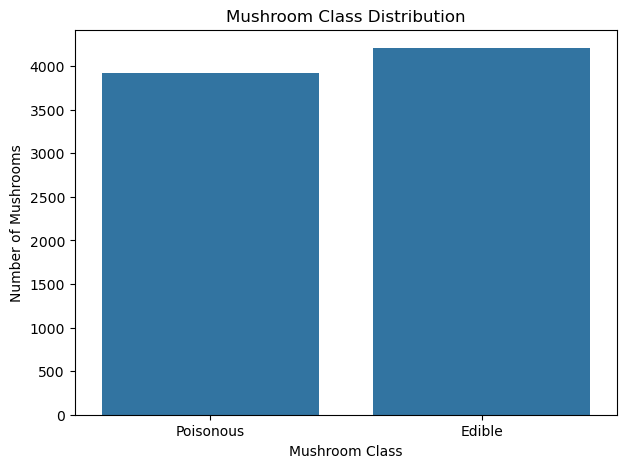

In [16]:
#Target Visualization
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="class"
)

plt.title("Mushroom Class Distribution")
plt.xlabel("Mushroom Class")
plt.ylabel("Number of Mushrooms")

plt.show()

In [17]:
#Check Missing Values
(df == "?").sum().sort_values(
    ascending=False
)

stalk-root                  2480
cap-shape                      0
class                          0
cap-color                      0
bruises                        0
odor                           0
cap-surface                    0
gill-attachment                0
gill-spacing                   0
gill-color                     0
gill-size                      0
stalk-shape                    0
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [18]:
# Replace ? to NaN
df = df.replace("?", np.nan)

df.isnull().sum().sort_values(
    ascending=False
)

stalk-root                  2480
cap-shape                      0
class                          0
cap-color                      0
bruises                        0
odor                           0
cap-surface                    0
gill-attachment                0
gill-spacing                   0
gill-color                     0
gill-size                      0
stalk-shape                    0
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [19]:

#SECTION 2 — Exploratory Data Analysis


In [20]:
#Check Duplicate Rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")

print("Dataset shape:", df.shape)

Number of duplicate rows: 0
No duplicate rows found.
Dataset shape: (8124, 23)


In [21]:
#Check Data Types
df.dtypes

class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object

In [22]:
#Unique Values
unique_values = df.nunique().sort_values()

unique_values

veil-type                    1
class                        2
gill-attachment              2
gill-spacing                 2
stalk-shape                  2
gill-size                    2
bruises                      2
ring-number                  3
stalk-surface-below-ring     4
stalk-surface-above-ring     4
cap-surface                  4
stalk-root                   4
veil-color                   4
ring-type                    5
cap-shape                    6
population                   6
habitat                      7
odor                         9
stalk-color-above-ring       9
stalk-color-below-ring       9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64

In [23]:
#Categories of Every Feature
for column in df.columns:
    print(f"\n{column}")
    print(df[column].dropna().unique())


class
['Poisonous' 'Edible']

cap-shape
['x' 'b' 's' 'f' 'k' 'c']

cap-surface
['s' 'y' 'f' 'g']

cap-color
['n' 'y' 'w' 'g' 'e' 'p' 'b' 'u' 'c' 'r']

bruises
['t' 'f']

odor
['p' 'a' 'l' 'n' 'f' 'c' 'y' 's' 'm']

gill-attachment
['f' 'a']

gill-spacing
['c' 'w']

gill-size
['n' 'b']

gill-color
['k' 'n' 'g' 'p' 'w' 'h' 'u' 'e' 'b' 'r' 'y' 'o']

stalk-shape
['e' 't']

stalk-root
['e' 'c' 'b' 'r']

stalk-surface-above-ring
['s' 'f' 'k' 'y']

stalk-surface-below-ring
['s' 'f' 'y' 'k']

stalk-color-above-ring
['w' 'g' 'p' 'n' 'b' 'e' 'o' 'c' 'y']

stalk-color-below-ring
['w' 'p' 'g' 'b' 'n' 'e' 'y' 'o' 'c']

veil-type
['p']

veil-color
['w' 'n' 'o' 'y']

ring-number
['o' 't' 'n']

ring-type
['p' 'e' 'l' 'f' 'n']

spore-print-color
['k' 'n' 'u' 'h' 'w' 'r' 'o' 'y' 'b']

population
['s' 'n' 'a' 'v' 'y' 'c']

habitat
['u' 'g' 'm' 'd' 'p' 'w' 'l']


In [24]:

#SECTION 3 — Mushroom Feature Dictionary


In [25]:
#Cap Shape
cap_shape_map = {
    "b": "bell",
    "c": "conical",
    "x": "convex",
    "f": "flat",
    "k": "knobbed",
    "s": "sunken"
}

df["cap-shape-label"] = df["cap-shape"].map(cap_shape_map)

df[
    ["cap-shape", "cap-shape-label"]
].head()

,cap-shape,cap-shape-label
0,x,convex
1,x,convex
2,b,bell
3,x,convex
4,x,convex


In [26]:
#Cap Surface
cap_surface_map = {
    "f": "fibrous",
    "g": "grooves",
    "y": "scaly",
    "s": "smooth"
}

df["cap-surface-label"] = df["cap-surface"].map(
    cap_surface_map
)

df[
    ["cap-surface", "cap-surface-label"]
].head()

,cap-surface,cap-surface-label
0,s,smooth
1,s,smooth
2,s,smooth
3,y,scaly
4,s,smooth


In [27]:
#Cap Color
cap_color_map = {
    "n": "brown",
    "b": "buff",
    "c": "cinnamon",
    "g": "gray",
    "r": "green",
    "p": "pink",
    "u": "purple",
    "e": "red",
    "w": "white",
    "y": "yellow"
}

df["cap-color-label"] = df["cap-color"].map(
    cap_color_map
)

df[
    ["cap-color", "cap-color-label"]
].head()

,cap-color,cap-color-label
0,n,brown
1,y,yellow
2,w,white
3,w,white
4,g,gray


In [28]:
#Bruises
bruises_map = {
    "t": "bruises",
    "f": "does_not_bruise"
}

df["bruises-label"] = df["bruises"].map(
    bruises_map
)

df[
    ["bruises", "bruises-label"]
].head()

,bruises,bruises-label
0,t,bruises
1,t,bruises
2,t,bruises
3,t,bruises
4,f,does_not_bruise


In [29]:
#Odor
odor_map = {
    "a": "almond",
    "l": "anise",
    "c": "creosote",
    "y": "fishy",
    "f": "foul",
    "m": "musty",
    "n": "none",
    "p": "pungent",
    "s": "spicy"
}

df["odor-label"] = df["odor"].map(
    odor_map
)

df[
    ["odor", "odor-label"]
].head()

,odor,odor-label
0,p,pungent
1,a,almond
2,l,anise
3,p,pungent
4,n,none


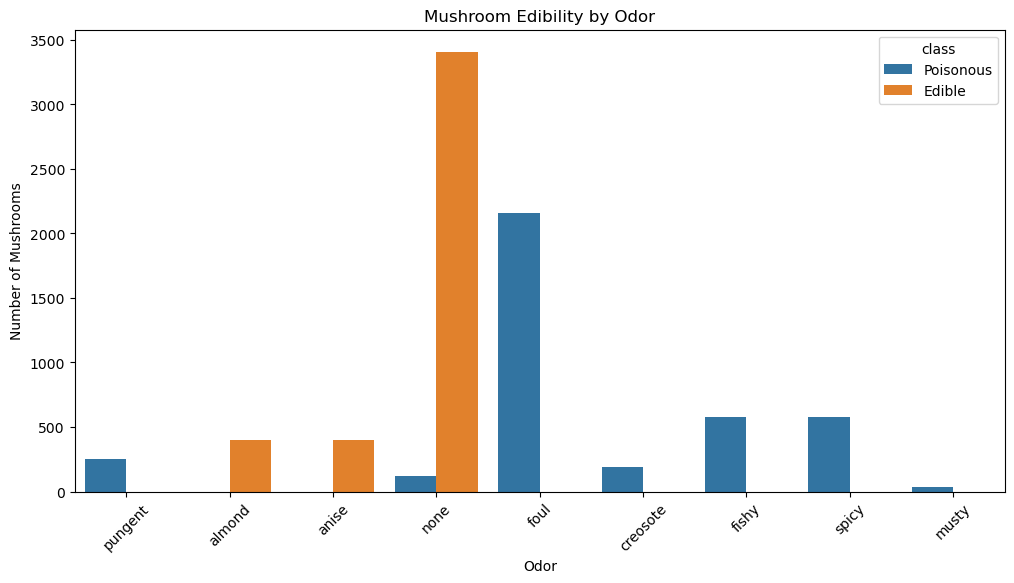

In [30]:
#Visualize Odor vs Edibility
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="odor-label",
    hue="class"
)

plt.title("Mushroom Edibility by Odor")
plt.xlabel("Odor")
plt.ylabel("Number of Mushrooms")

plt.xticks(rotation=45)

plt.show()

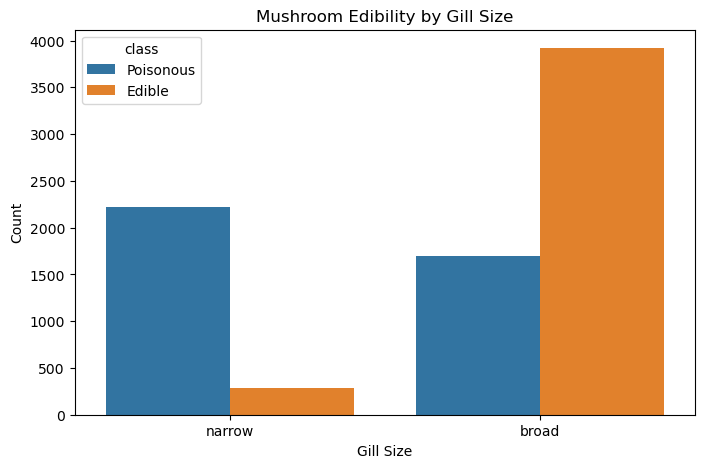

In [31]:
#Gill Size vs Class
gill_size_map = {
    "b": "broad",
    "n": "narrow"
}

df["gill-size-label"] = df["gill-size"].map(
    gill_size_map
)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="gill-size-label",
    hue="class"
)

plt.title("Mushroom Edibility by Gill Size")
plt.xlabel("Gill Size")
plt.ylabel("Count")

plt.show()

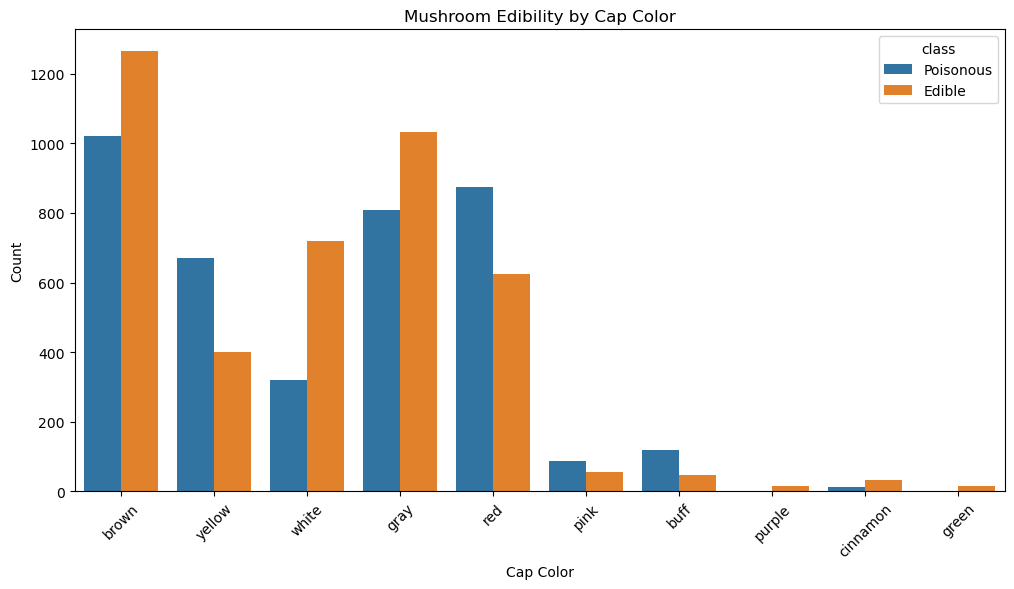

In [32]:
#Cap Color vs Class
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="cap-color-label",
    hue="class"
)

plt.title("Mushroom Edibility by Cap Color")
plt.xlabel("Cap Color")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

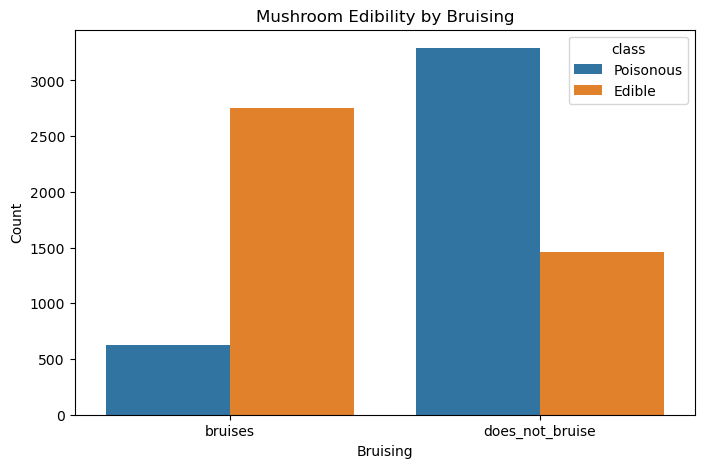

In [33]:
#Bruises vs Class
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="bruises-label",
    hue="class"
)

plt.title("Mushroom Edibility by Bruising")
plt.xlabel("Bruising")
plt.ylabel("Count")

plt.show()

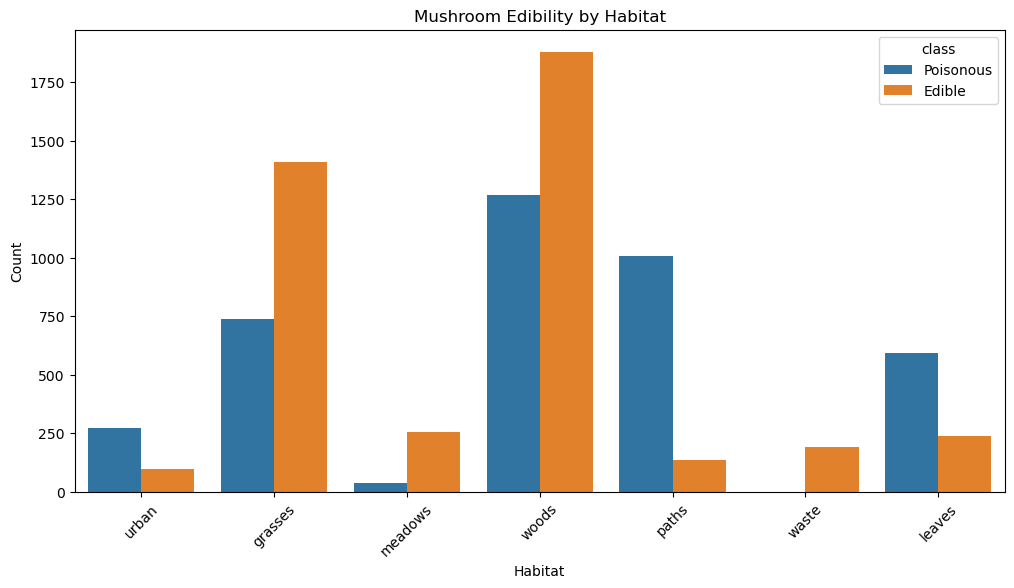

In [34]:
#Habitat vs Class
habitat_map = {
    "g": "grasses",
    "l": "leaves",
    "m": "meadows",
    "p": "paths",
    "u": "urban",
    "w": "waste",
    "d": "woods"
}

df["habitat-label"] = df["habitat"].map(
    habitat_map
)

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="habitat-label",
    hue="class"
)

plt.title("Mushroom Edibility by Habitat")
plt.xlabel("Habitat")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

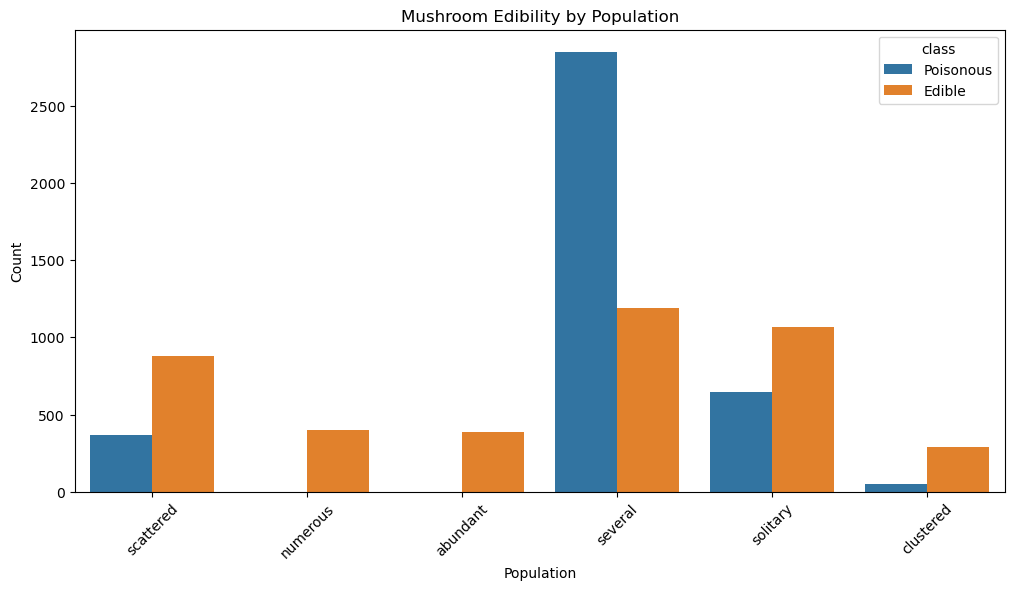

In [35]:
#Population vs Class
population_map = {
    "a": "abundant",
    "c": "clustered",
    "n": "numerous",
    "s": "scattered",
    "v": "several",
    "y": "solitary"
}

df["population-label"] = df["population"].map(
    population_map
)

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="population-label",
    hue="class"
)

plt.title("Mushroom Edibility by Population")
plt.xlabel("Population")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

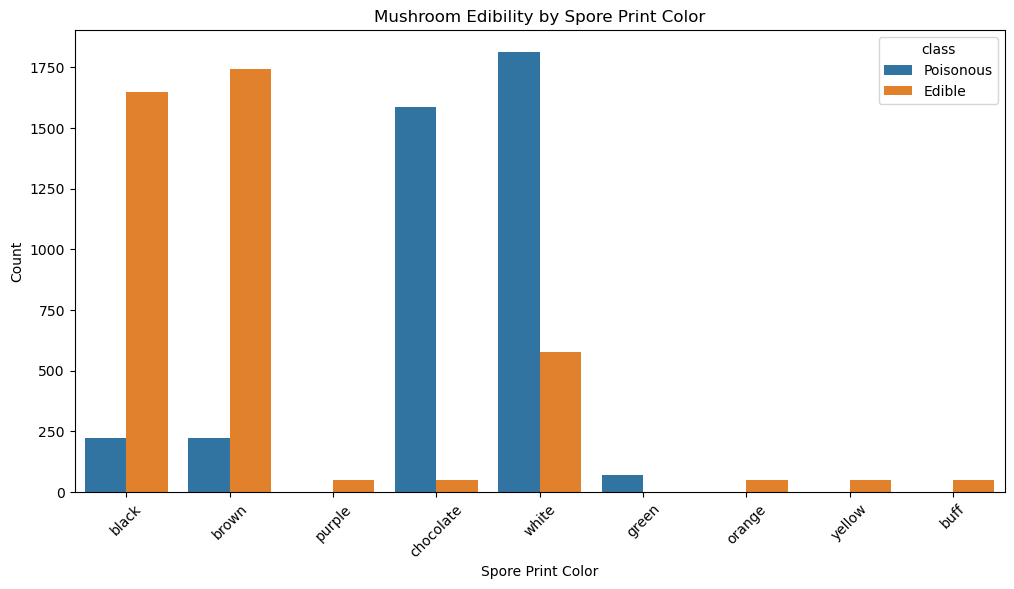

In [36]:
#Spore Print Color
spore_map = {
    "k": "black",
    "n": "brown",
    "b": "buff",
    "h": "chocolate",
    "r": "green",
    "o": "orange",
    "u": "purple",
    "w": "white",
    "y": "yellow"
}

df["spore-print-color-label"] = df[
    "spore-print-color"
].map(spore_map)

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="spore-print-color-label",
    hue="class"
)

plt.title("Mushroom Edibility by Spore Print Color")
plt.xlabel("Spore Print Color")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [37]:

#SECTION 4 — Feature vs Target Relationship


In [38]:
#Import Chi-Square
from scipy.stats import chi2_contingency

In [39]:
#Cramér's V Function
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion)[0]

    n = confusion.sum().sum()

    phi2 = chi2 / n

    r, k = confusion.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(
        phi2corr /
        min(
            kcorr - 1,
            rcorr - 1
        )
    )

In [41]:
#Calculate Feature Associations
original_features = [
    column for column in columns
    if column != "class"
]

association_scores = []

for feature in original_features:

    score = cramers_v(
        df[feature].fillna("Missing"),
        df["class"]
    )

    association_scores.append({
        "Feature": feature,
        "Cramers_V": score
    })

association_df = pd.DataFrame(
    association_scores
).sort_values(
    "Cramers_V",
    ascending=False
)

association_df

,Feature,Cramers_V
4,odor,0.970558
19,spore-print-color,0.752036
8,gill-color,0.679877
18,ring-type,0.602900
11,stalk-surface-above-ring,0.587666
12,stalk-surface-below-ring,0.574551
7,gill-size,0.539677
13,stalk-color-above-ring,0.523943
14,stalk-color-below-ring,0.513799
3,bruises,0.501188


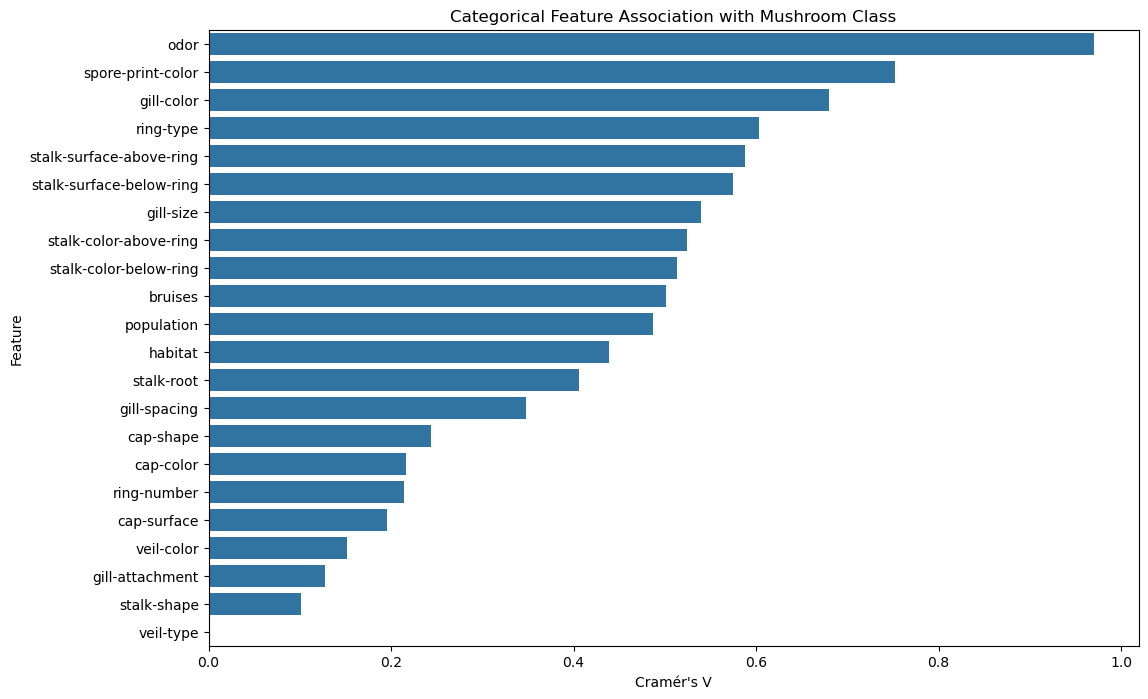

In [42]:
#Plot Feature Association
plt.figure(figsize=(12, 8))

sns.barplot(
    data=association_df,
    x="Cramers_V",
    y="Feature"
)

plt.title(
    "Categorical Feature Association with Mushroom Class"
)

plt.xlabel("Cramér's V")
plt.ylabel("Feature")

plt.show()

In [43]:

#SECTION 5 — Prepare Data for Machine Learning


In [44]:
df_model = df[columns].copy()

print("Model dataset shape:", df_model.shape)

Model dataset shape: (8124, 23)


In [45]:
#Separate Features and Target
X = df_model.drop(
    "class",
    axis=1
)

y = df_model["class"]

In [46]:
#Encode Target
y = y.map({
    "Edible": 0,
    "Poisonous": 1
})

print(y.value_counts())

class
0    4208
1    3916
Name: count, dtype: int64


In [47]:
#Verify X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (8124, 22)
y shape: (8124,)

Features:
['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


In [48]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 6499
Testing samples: 1625


In [49]:
#Verify Class Distribution
print("Training class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training class distribution:
class
0    0.517926
1    0.482074
Name: proportion, dtype: float64

Testing class distribution:
class
0    0.518154
1    0.481846
Name: proportion, dtype: float64


In [50]:

#SECTION 6 — Create Preprocessing Pipeline


In [51]:
#Define Categorical Features
categorical_features = X.columns.tolist()

print(
    "Number of categorical features:",
    len(categorical_features)
)

Number of categorical features: 22


In [52]:
#Create Preprocessor
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [54]:

#SECTION 7 — TRAIN THE MODELS


In [55]:
results = []

In [56]:
#Create Evaluation Function
def evaluate_model(name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    print("\nClassification Report:")
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Edible", "Poisonous"]
        )
    )
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })
    
    return y_pred

In [57]:
#LOGISTIC REGRESSION

# Create the model

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)
print("Logistic Regression model created!")

# Train the model

logistic_model.fit(
    X_train,
    y_train
)
print("Logistic Regression trained!")

# Predict

y_pred_logistic = logistic_model.predict(
    X_test
)

# Accuracy

logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

print("===== LOGISTIC REGRESSION =====")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)

Logistic Regression model created!
Logistic Regression trained!
===== LOGISTIC REGRESSION =====
Accuracy : 0.9987692307692307
Precision: 1.0
Recall   : 0.9974457215836526
F1 Score : 0.9987212276214834


In [58]:
#LINEAR REGRESSION

#Create the model

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]
)

print("Linear Regression model created!")

#Train the model

linear_model.fit(
    X_train,
    y_train
)

print("Linear Regression trained!")

#Predict 

linear_predictions = linear_model.predict(
    X_test
)

y_pred_linear = (
    linear_predictions >= 0.5
).astype(int)

#Accuracy

linear_accuracy = accuracy_score(
    y_test,
    y_pred_linear
)

linear_precision = precision_score(
    y_test,
    y_pred_linear
)

linear_recall = recall_score(
    y_test,
    y_pred_linear
)

linear_f1 = f1_score(
    y_test,
    y_pred_linear
)

print("===== LINEAR REGRESSION =====")
print("Accuracy :", linear_accuracy)
print("Precision:", linear_precision)
print("Recall   :", linear_recall)
print("F1 Score :", linear_f1)

Linear Regression model created!
Linear Regression trained!
===== LINEAR REGRESSION =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [59]:
### Note on Linear Regression

#Linear Regression is fundamentally a regression algorithm rather than a classification algorithm. It is included in this project because it was specified as a required model.

#The continuous output is converted into a binary class using a threshold:

# Prediction < 0.5 → Edible
# Prediction ≥ 0.5 → Poisonous

#Therefore, its results should be interpreted as a baseline comparison rather than as a standard classification implementation.

In [60]:
#SUPPORT VECTOR MACHINE

#Create the model

svm_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            SVC(
                kernel="rbf"
            )
        )
    ]
)

print("SVM model created!")

#Train the model

svm_model.fit(
    X_train,
    y_train
)

print("SVM trained!")

#Predict 

y_pred_svm = svm_model.predict(
    X_test
)

#Accuracy

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_precision = precision_score(
    y_test,
    y_pred_svm
)

svm_recall = recall_score(
    y_test,
    y_pred_svm
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm
)

print("===== SVM =====")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

SVM model created!
SVM trained!
===== SVM =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [61]:
#KNN
#Create the model

knn_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=5
            )
        )
    ]
)

print("KNN model created!")

#Train the model

knn_model.fit(
    X_train,
    y_train
)

print("KNN trained!")

#Predict 

y_pred_knn = knn_model.predict(
    X_test
)

#Accuracy

knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

knn_precision = precision_score(
    y_test,
    y_pred_knn
)

knn_recall = recall_score(
    y_test,
    y_pred_knn
)

knn_f1 = f1_score(
    y_test,
    y_pred_knn
)

print("===== KNN =====")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN model created!
KNN trained!
===== KNN =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [63]:
#Decision Tree
#Create the model

decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

print("Decision Tree model created!")

#Train the model

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree trained!")

#Predict 

y_pred_dt = decision_tree_model.predict(
    X_test
)

#Accuracy

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt
)

dt_recall = recall_score(
    y_test,
    y_pred_dt
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt
)

print("===== DECISION TREE =====")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree model created!
Decision Tree trained!
===== DECISION TREE =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [64]:
#Random Forset 
#Create the model

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest model created!")

#Train the model

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained!")

#Predict 

y_pred_rf = random_forest_model.predict(
    X_test
)

#Accuracy

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

print("===== RANDOM FOREST =====")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest model created!
Random Forest trained!
===== RANDOM FOREST =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [65]:
#Compare all the model
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1 Score": logistic_f1
    },
    {
        "Model": "Linear Regression",
        "Accuracy": linear_accuracy,
        "Precision": linear_precision,
        "Recall": linear_recall,
        "F1 Score": linear_f1
    },
    {
        "Model": "SVM",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1 Score": svm_f1
    },
    {
        "Model": "KNN",
        "Accuracy": knn_accuracy,
        "Precision": knn_precision,
        "Recall": knn_recall,
        "F1 Score": knn_f1
    },
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1 Score": dt_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.998769,1.0,0.997446,0.998721
1,Linear Regression,1.000000,1.0,1.000000,1.000000
2,SVM,1.000000,1.0,1.000000,1.000000
3,KNN,1.000000,1.0,1.000000,1.000000
4,Decision Tree,1.000000,1.0,1.000000,1.000000
5,Random Forest,1.000000,1.0,1.000000,1.000000


In [68]:
#Sort From Best to Worst
#F1 score
f1_results = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

f1_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear Regression,1.000000,1.0,1.000000,1.000000
1,SVM,1.000000,1.0,1.000000,1.000000
2,Decision Tree,1.000000,1.0,1.000000,1.000000
3,KNN,1.000000,1.0,1.000000,1.000000
4,Random Forest,1.000000,1.0,1.000000,1.000000
5,Logistic Regression,0.998769,1.0,0.997446,0.998721


In [69]:
#Accuracy
accuracy_results = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

accuracy_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear Regression,1.000000,1.0,1.000000,1.000000
1,SVM,1.000000,1.0,1.000000,1.000000
2,Decision Tree,1.000000,1.0,1.000000,1.000000
3,KNN,1.000000,1.0,1.000000,1.000000
4,Random Forest,1.000000,1.0,1.000000,1.000000
5,Logistic Regression,0.998769,1.0,0.997446,0.998721


In [72]:
#Best Model
best_model = f1_results.iloc[0]

print("Best Model:", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"], 6))
print("Precision:", round(best_model["Precision"], 6))
print("Recall   :", round(best_model["Recall"], 6))
print("F1 Score :", round(best_model["F1 Score"], 6))

Best Model: Linear Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [73]:
#CROSS VALIDATION
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": logistic_model,
    "SVM": svm_model,
    "KNN": knn_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1"
        ],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1
0,Logistic Regression,0.999754,1.0,0.999489,0.999744
1,SVM,1.000000,1.0,1.000000,1.000000
2,KNN,1.000000,1.0,1.000000,1.000000
3,Decision Tree,1.000000,1.0,1.000000,1.000000
4,Random Forest,1.000000,1.0,1.000000,1.000000


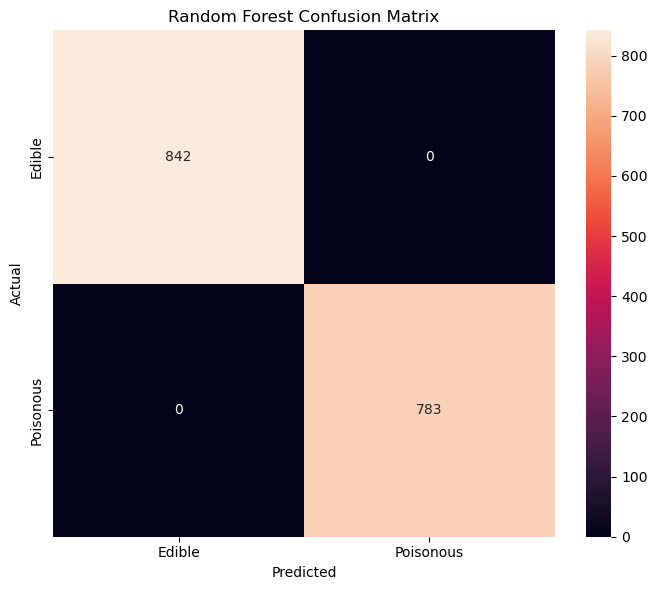

In [74]:
#Random Forest confusion matrix
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Edible", "Poisonous"],
    yticklabels=["Edible", "Poisonous"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../figures/confusion_matrix_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
#Random Forest feature importance
rf_preprocessor = random_forest_model.named_steps[
    "preprocessor"
]

rf_classifier = random_forest_model.named_steps[
    "classifier"
]

feature_names = (
    rf_preprocessor.get_feature_names_out()
)

importances = (
    rf_classifier.feature_importances_
)

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
27,categorical__odor_n,0.111739
24,categorical__odor_f,0.064471
35,categorical__gill-size_b,0.056231
36,categorical__gill-size_n,0.056224
37,categorical__gill-color_b,0.044917
95,categorical__spore-print-color_h,0.042857
60,categorical__stalk-surface-below-ring_k,0.042113
56,categorical__stalk-surface-above-ring_k,0.039932
93,categorical__ring-type_p,0.033200
20,categorical__bruises_f,0.029458


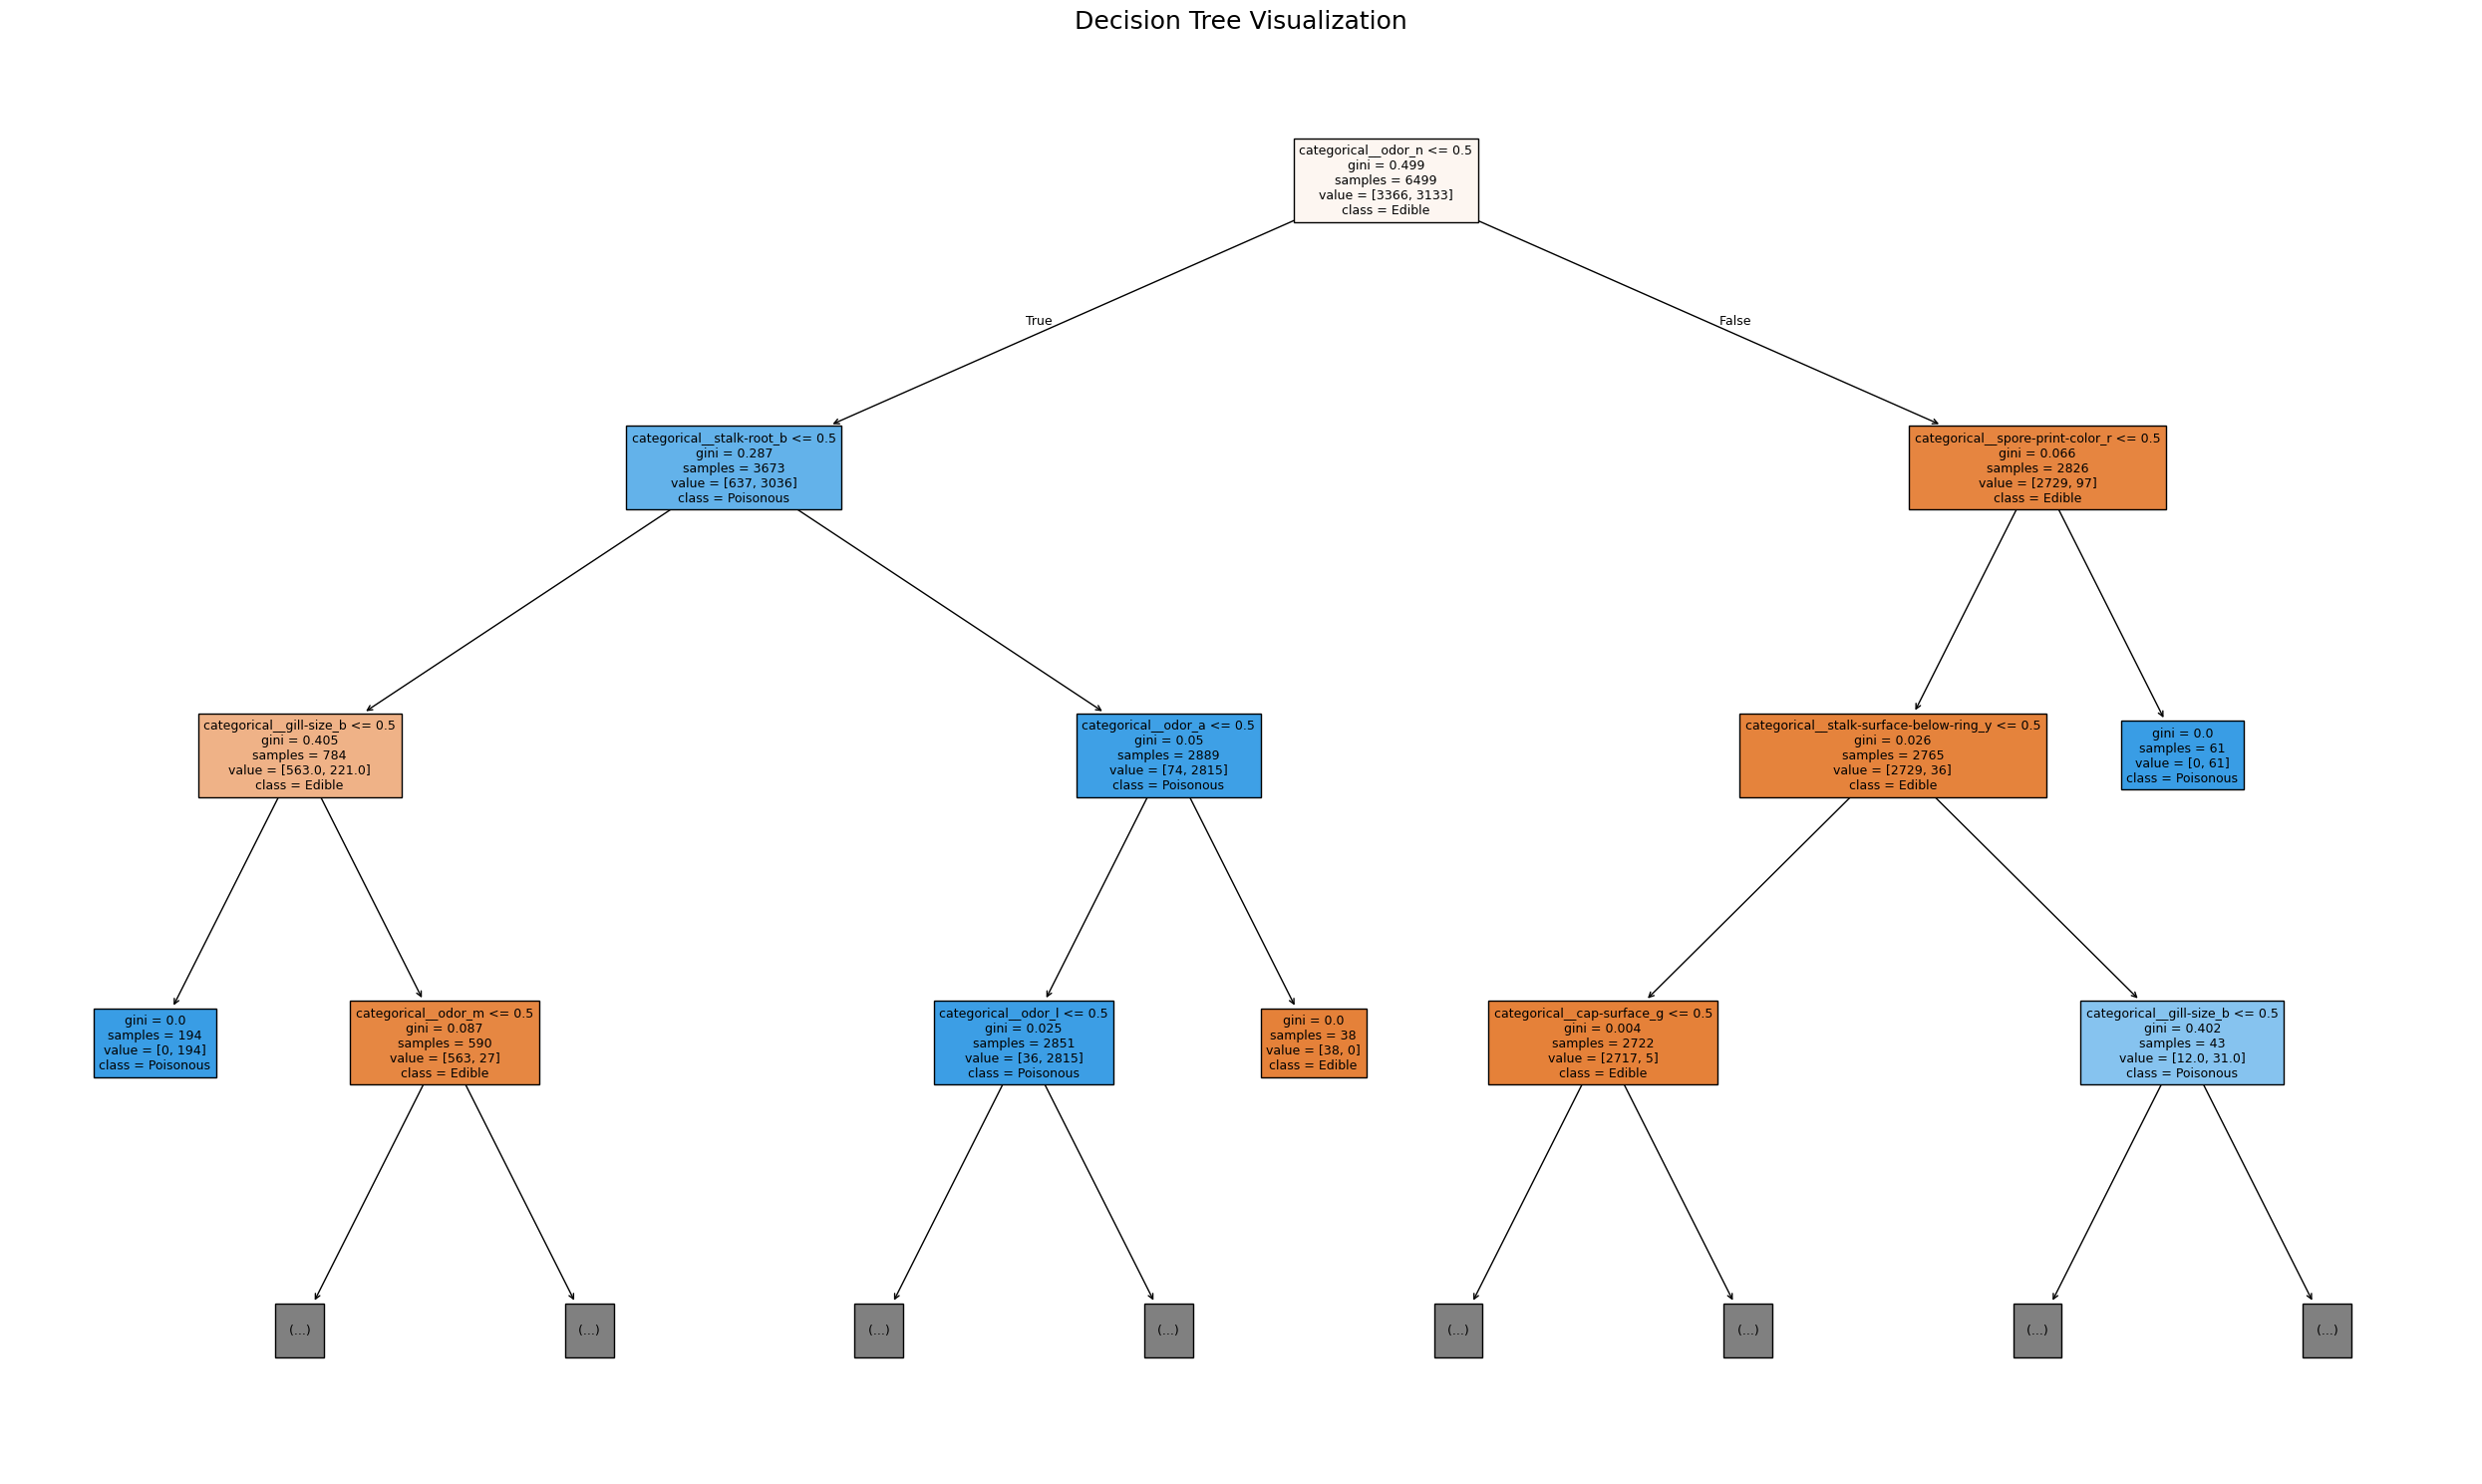

In [77]:
#Decision Tree visualization
dt_preprocessor = decision_tree_model.named_steps[
    "preprocessor"
]

dt_classifier = decision_tree_model.named_steps[
    "classifier"
]

dt_feature_names = (
    dt_preprocessor.get_feature_names_out()
)

plt.figure(figsize=(25, 15))

plot_tree(
    dt_classifier,
    feature_names=dt_feature_names,
    class_names=[
        "Edible",
        "Poisonous"
    ],
    filled=True,
    max_depth=3,
    fontsize=9
)

plt.title(
    "Decision Tree Visualization",
    fontsize=18
)

plt.tight_layout()

plt.savefig(
    "../figures/decision_tree_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
# SAVE TRAINED MODELS
os.makedirs("../models", exist_ok=True)

joblib.dump(
    logistic_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    linear_model,
    "../models/linear_regression.pkl"
)

joblib.dump(
    svm_model,
    "../models/svm.pkl"
)

joblib.dump(
    knn_model,
    "../models/knn.pkl"
)

joblib.dump(
    decision_tree_model,
    "../models/decision_tree.pkl"
)

joblib.dump(
    random_forest_model,
    "../models/random_forest.pkl"
)

print("All six models saved successfully!")

All six models saved successfully!
